# LTA Raman Spectroscopy Analysis
## 20 sec Integration, 20 Power - Variable Location Study

**Sample:** LTA Powder  
**Acquisition:** 20 sec integration, 20 power  
**Number of Spots:** 12 spatial locations  

**Analysis Pipeline:**
1. Load all 12 datasets
2. Baseline correction
3. Savitzky-Golay smoothing
4. Normalization
5. Peak detection & labeling
6. Spot-to-spot variability analysis
7. Average spectrum generation

---
## 1. Import Required Libraries

In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import savgol_filter, find_peaks
from scipy.sparse import csc_matrix, eye, diags
from scipy.sparse.linalg import spsolve
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


---
## 2. Load All 12 Datasets

We'll load all cleaned Excel files and extract:
- **Column C (index 2):** Raman Shift (cm⁻¹)
- **Column D (index 3):** Dark-Subtracted Intensity
- **Filter range:** 500-2000 cm⁻¹ (fingerprint region)

In [40]:
# Get current directory
folder_path = os.getcwd()

# Find all cleaned files
cleaned_files = sorted([f for f in os.listdir(folder_path) 
                       if f.startswith('cleaned_SP_') and f.endswith('.xlsx')])

print(f"Found {len(cleaned_files)} cleaned files:\n")
for f in cleaned_files:
    print(f"  • {f}")

# Dictionary to store all datasets
raman_data = {}

# Load each file
for file in cleaned_files:
    # Extract spot number from filename (e.g., cleaned_SP_10.xlsx -> Spot_10)
    spot_num = file.replace('cleaned_SP_', '').replace('.xlsx', '')
    spot_name = f'Spot_{spot_num}'
    
    # Read Excel file
    file_path = os.path.join(folder_path, file)
    df = pd.read_excel(file_path, header=None)
    
    # Extract Raman Shift (Column C, index 2) and Intensity (Column D, index 3)
    # Skip first 3 rows which contain metadata (A20, B20, A21, B21, A40, B40)
    raman_shift = pd.to_numeric(df.iloc[3:, 2], errors='coerce').dropna().values
    intensity = pd.to_numeric(df.iloc[3:, 3], errors='coerce').dropna().values
    
    # Ensure same length
    min_len = min(len(raman_shift), len(intensity))
    raman_shift = np.array(raman_shift[:min_len], dtype=np.float64)
    intensity = np.array(intensity[:min_len], dtype=np.float64)
    
    # Filter to keep only 500-2000 cm⁻¹ range
    mask = (raman_shift >= 500) & (raman_shift <= 2000)
    raman_shift = raman_shift[mask]
    intensity = intensity[mask]
    
    # Store in dictionary
    raman_data[spot_name] = {
        'shift': raman_shift,
        'intensity': intensity
    }

print(f"\n✓ Loaded {len(raman_data)} spectra successfully")
print(f"✓ Filtered to 500-2000 cm⁻¹ range")
print(f"\nFirst dataset shape: {len(raman_data[list(raman_data.keys())[0]]['shift'])} points")
print(f"Raman shift range: {raman_data[list(raman_data.keys())[0]]['shift'].min():.1f} - {raman_data[list(raman_data.keys())[0]]['shift'].max():.1f} cm⁻¹")

Found 12 cleaned files:

  • cleaned_SP_10.xlsx
  • cleaned_SP_11.xlsx
  • cleaned_SP_12.xlsx
  • cleaned_SP_13.xlsx
  • cleaned_SP_14.xlsx
  • cleaned_SP_2.xlsx
  • cleaned_SP_3.xlsx
  • cleaned_SP_4.xlsx
  • cleaned_SP_5.xlsx
  • cleaned_SP_6.xlsx
  • cleaned_SP_7.xlsx
  • cleaned_SP_8.xlsx

✓ Loaded 12 spectra successfully
✓ Filtered to 500-2000 cm⁻¹ range

First dataset shape: 993 points
Raman shift range: 501.6 - 1999.0 cm⁻¹


---
## 3. Plot Raw Spectra

Visualize all 12 raw spectra to check:
- Intensity variations between spots
- Baseline drift
- Noise levels
- Peak consistency

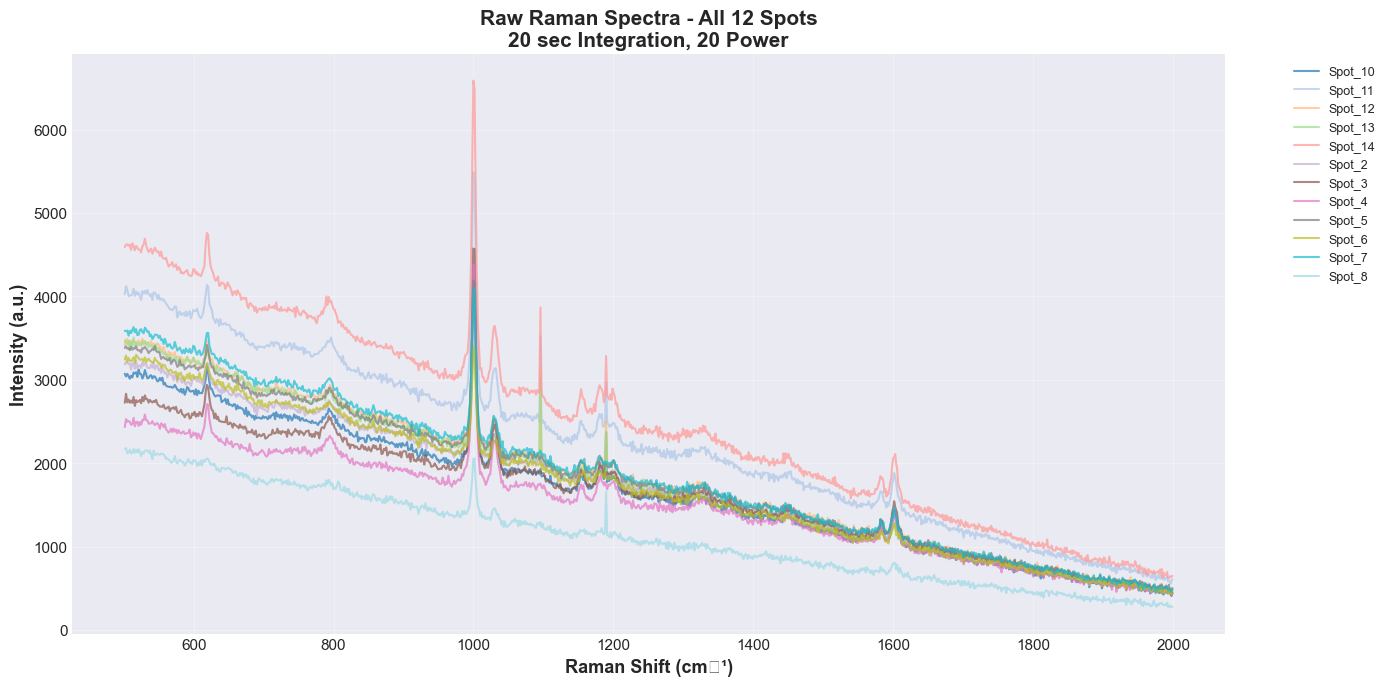

✓ Raw spectra plotted


In [41]:
plt.figure(figsize=(14, 7))

# Color map for different spots
colors = plt.cm.tab20(np.linspace(0, 1, len(raman_data)))

for idx, (spot_name, data) in enumerate(raman_data.items()):
    plt.plot(data['shift'], data['intensity'], 
             label=spot_name, alpha=0.7, linewidth=1.5, color=colors[idx])

plt.xlabel('Raman Shift (cm⁻¹)', fontsize=13, fontweight='bold')
plt.ylabel('Intensity (a.u.)', fontsize=13, fontweight='bold')
plt.title('Raw Raman Spectra - All 12 Spots\n20 sec Integration, 20 Power', 
          fontsize=15, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Raw spectra plotted")

---
## 4. Baseline Correction

Using **Asymmetric Least Squares (ALS)** method to remove:
- Fluorescence background
- Sloping baseline
- Instrumental drift

**Parameters:**
- `lam`: Smoothness (10² to 10⁹, higher = smoother)
- `p`: Asymmetry (0.001 to 0.1, lower = more asymmetric)

In [42]:
def baseline_als(y, lam=1e6, p=0.01, niter=10):
    """
    Asymmetric Least Squares baseline correction
    
    Parameters:
    -----------
    y : array
        Input signal
    lam : float
        Smoothness parameter (10^2 to 10^9)
    p : float
        Asymmetry parameter (0.001 to 0.1)
    niter : int
        Number of iterations
    
    Returns:
    --------
    z : array
        Fitted baseline
    """
    L = len(y)
    D = csc_matrix(np.diff(np.eye(L), 2))
    w = np.ones(L)
    
    for i in range(niter):
        W = diags(w, 0, shape=(L, L))
        Z = W + lam * D.dot(D.transpose())
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y < z)
    
    return z

# Apply baseline correction to all datasets
raman_data_corrected = {}

for spot_name, data in raman_data.items():
    # Calculate baseline
    baseline = baseline_als(data['intensity'], lam=1e6, p=0.01, niter=10)
    
    # Subtract baseline
    corrected_intensity = data['intensity'] - baseline
    
    # Store corrected data
    raman_data_corrected[spot_name] = {
        'shift': data['shift'],
        'intensity': corrected_intensity,
        'baseline': baseline
    }

print("✓ Baseline correction completed for all 12 spectra")

✓ Baseline correction completed for all 12 spectra


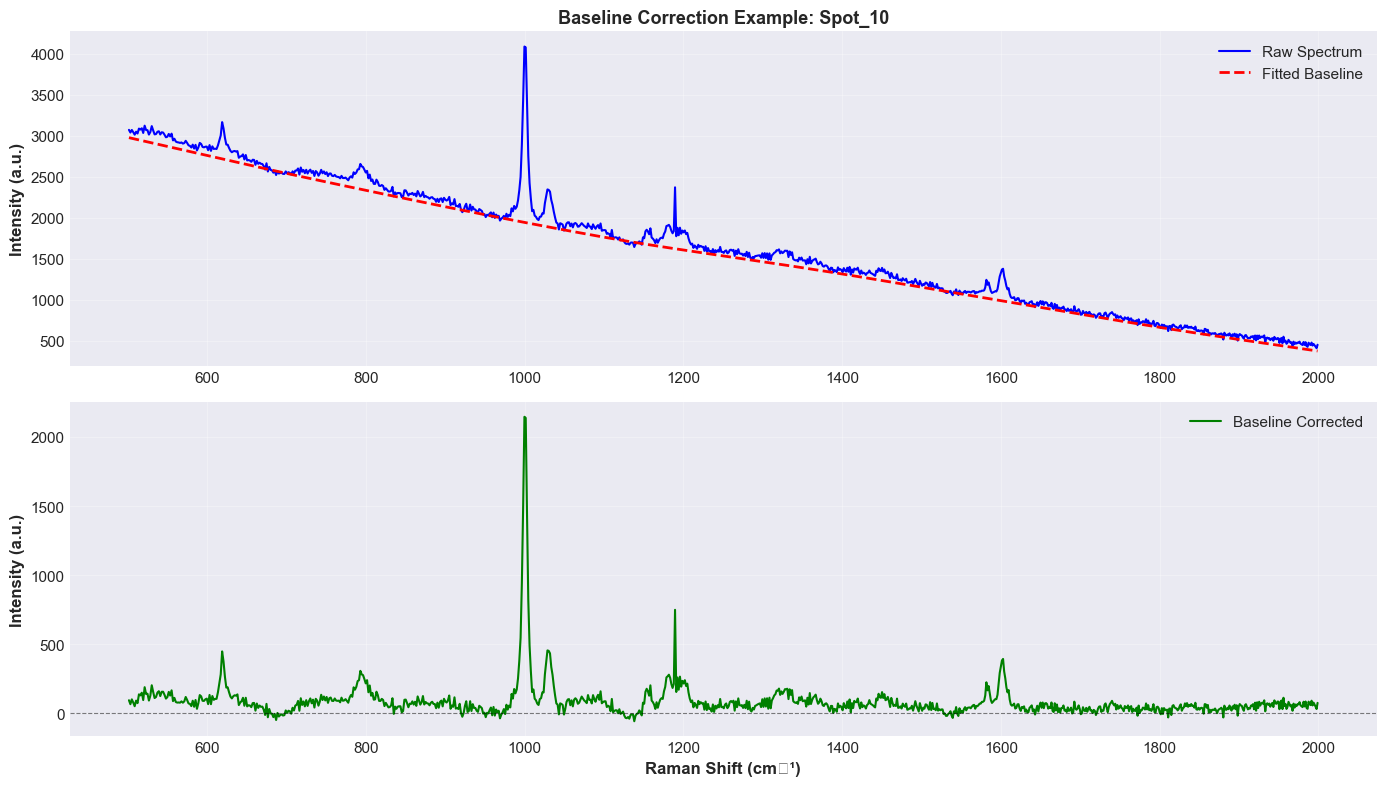

In [43]:
# Visualize baseline correction (example: first spot)
example_spot = list(raman_data.keys())[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Before correction
axes[0].plot(raman_data[example_spot]['shift'], 
             raman_data[example_spot]['intensity'], 
             label='Raw Spectrum', color='blue', linewidth=1.5)
axes[0].plot(raman_data_corrected[example_spot]['shift'], 
             raman_data_corrected[example_spot]['baseline'], 
             label='Fitted Baseline', color='red', linewidth=2, linestyle='--')
axes[0].set_ylabel('Intensity (a.u.)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Baseline Correction Example: {example_spot}', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After correction
axes[1].plot(raman_data_corrected[example_spot]['shift'], 
             raman_data_corrected[example_spot]['intensity'], 
             label='Baseline Corrected', color='green', linewidth=1.5)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_xlabel('Raman Shift (cm⁻¹)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Intensity (a.u.)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

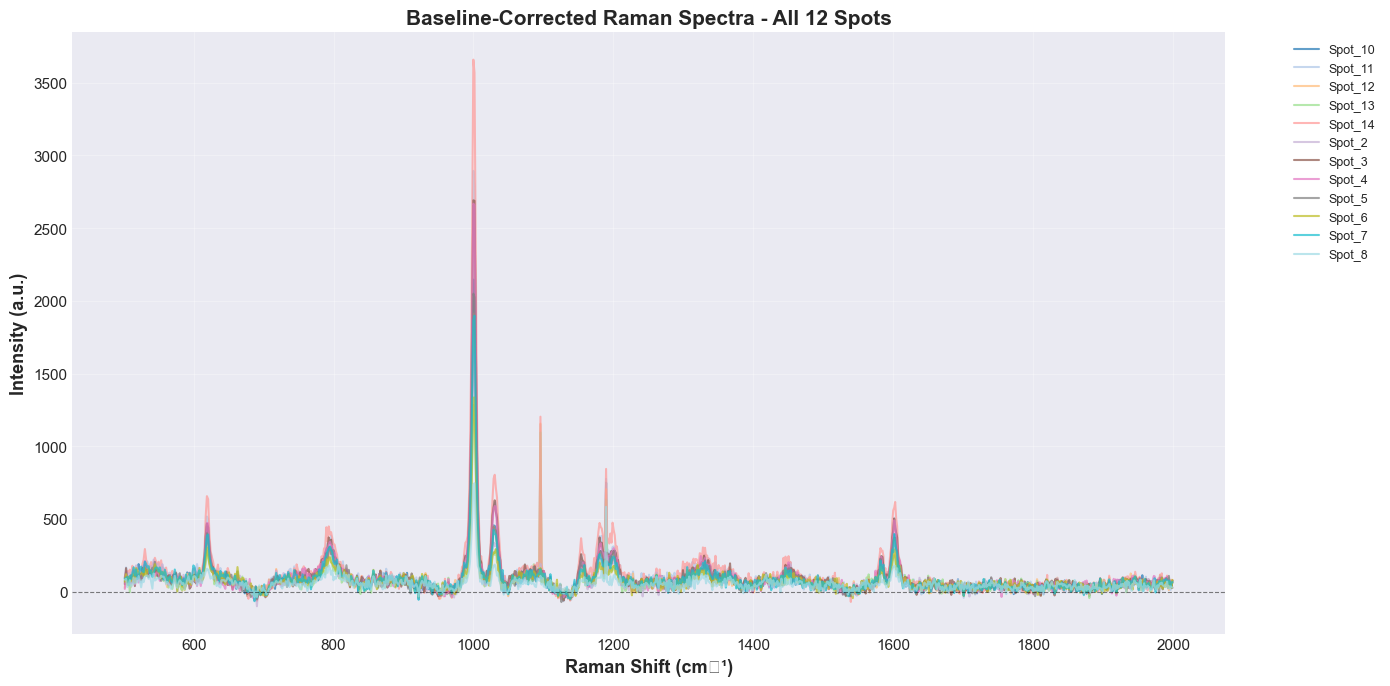

In [44]:
# Plot all baseline-corrected spectra
plt.figure(figsize=(14, 7))

colors = plt.cm.tab20(np.linspace(0, 1, len(raman_data_corrected)))

for idx, (spot_name, data) in enumerate(raman_data_corrected.items()):
    plt.plot(data['shift'], data['intensity'], 
             label=spot_name, alpha=0.7, linewidth=1.5, color=colors[idx])

plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
plt.xlabel('Raman Shift (cm⁻¹)', fontsize=13, fontweight='bold')
plt.ylabel('Intensity (a.u.)', fontsize=13, fontweight='bold')
plt.title('Baseline-Corrected Raman Spectra - All 12 Spots', fontsize=15, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Savitzky-Golay Smoothing

Removes noise while preserving peak shape.

**Parameters:**
- `window_length`: Must be odd (9, 11, 15, 21)
- `polyorder`: Polynomial order (2 or 3)

In [45]:
# Smoothing parameters
window_length = 15  # Must be odd
polyorder = 3

# Apply Savitzky-Golay filter to all baseline-corrected spectra
raman_data_smoothed = {}

for spot_name, data in raman_data_corrected.items():
    # Apply smoothing
    smoothed_intensity = savgol_filter(data['intensity'], 
                                       window_length=window_length, 
                                       polyorder=polyorder)
    
    # Store smoothed data
    raman_data_smoothed[spot_name] = {
        'shift': data['shift'],
        'intensity': smoothed_intensity
    }

print(f"✓ Savitzky-Golay smoothing applied (window={window_length}, order={polyorder})")

✓ Savitzky-Golay smoothing applied (window=15, order=3)


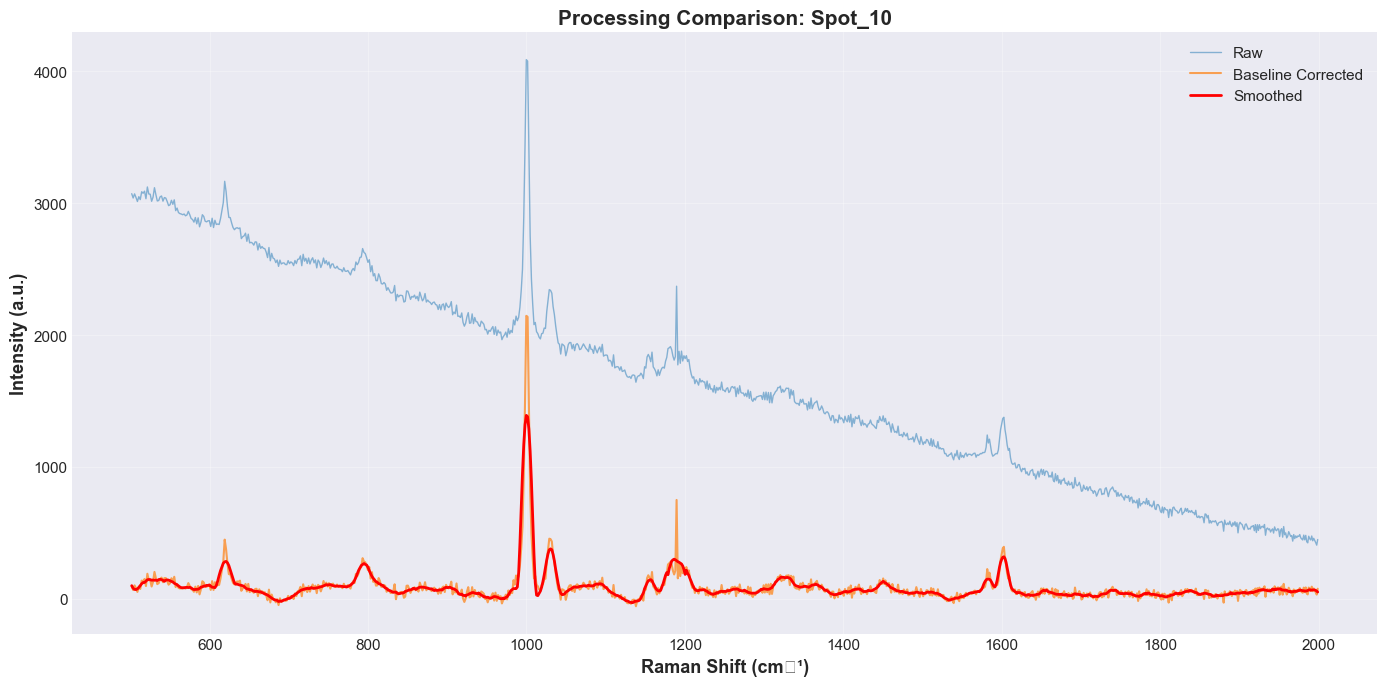

In [46]:
# Compare: Raw → Baseline Corrected → Smoothed
example_spot = list(raman_data.keys())[0]

plt.figure(figsize=(14, 7))

plt.plot(raman_data[example_spot]['shift'], 
         raman_data[example_spot]['intensity'], 
         label='Raw', alpha=0.5, linewidth=1)

plt.plot(raman_data_corrected[example_spot]['shift'], 
         raman_data_corrected[example_spot]['intensity'], 
         label='Baseline Corrected', alpha=0.7, linewidth=1.5)

plt.plot(raman_data_smoothed[example_spot]['shift'], 
         raman_data_smoothed[example_spot]['intensity'], 
         label='Smoothed', linewidth=2, color='red')

plt.xlabel('Raman Shift (cm⁻¹)', fontsize=13, fontweight='bold')
plt.ylabel('Intensity (a.u.)', fontsize=13, fontweight='bold')
plt.title(f'Processing Comparison: {example_spot}', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Normalization

Since different spots may have different laser coupling efficiency, we normalize.

**Method:** Area normalization (recommended for powder comparison)

In [47]:
# Apply area normalization to all smoothed spectra
raman_data_normalized = {}

for spot_name, data in raman_data_smoothed.items():
    # Calculate area under curve (using trapezoidal integration)
    area = np.trapezoid(np.abs(data['intensity']), data['shift'])
    
    # Normalize by area
    normalized_intensity = data['intensity'] / area if area > 0 else data['intensity']
    
    # Store normalized data
    raman_data_normalized[spot_name] = {
        'shift': data['shift'],
        'intensity': normalized_intensity
    }

print("✓ Area normalization completed for all 12 spectra")

✓ Area normalization completed for all 12 spectra


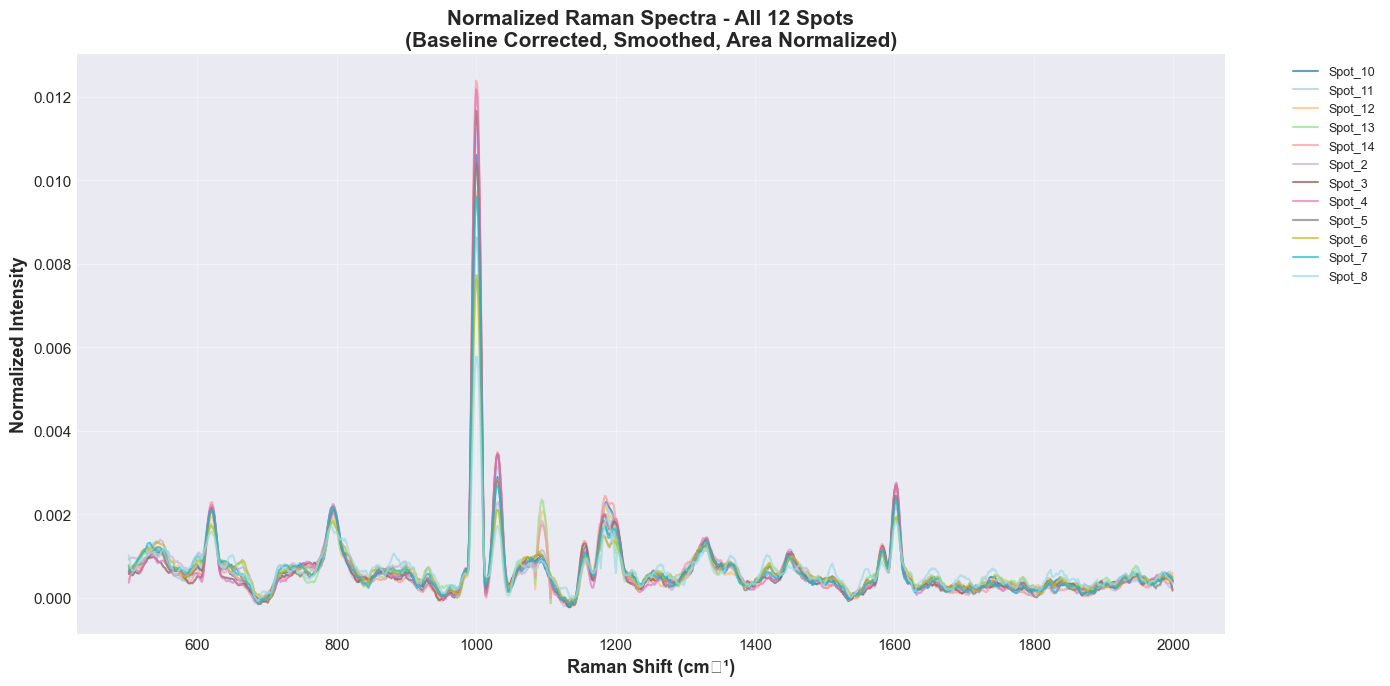


🎯 Spectra should now overlap nicely if the material is uniform across spots


In [48]:
# Plot all normalized spectra
plt.figure(figsize=(14, 7))

colors = plt.cm.tab20(np.linspace(0, 1, len(raman_data_normalized)))

for idx, (spot_name, data) in enumerate(raman_data_normalized.items()):
    plt.plot(data['shift'], data['intensity'], 
             label=spot_name, alpha=0.7, linewidth=1.5, color=colors[idx])

plt.xlabel('Raman Shift (cm⁻¹)', fontsize=13, fontweight='bold')
plt.ylabel('Normalized Intensity', fontsize=13, fontweight='bold')
plt.title('Normalized Raman Spectra - All 12 Spots\n(Baseline Corrected, Smoothed, Area Normalized)', 
          fontsize=15, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🎯 Spectra should now overlap nicely if the material is uniform across spots")

---
## 7. Peak Detection

Detect and label characteristic peaks in each spectrum.

In [49]:
# Peak detection parameters
prominence = 0.0001  # Adjust based on your normalized intensity scale
distance = 20  # Minimum distance between peaks (in data points)

# Dictionary to store peak information
peak_data = {}

for spot_name, data in raman_data_normalized.items():
    # Find peaks
    peaks, properties = find_peaks(data['intensity'], 
                                   prominence=prominence,
                                   distance=distance)
    
    # Extract peak positions and intensities
    peak_positions = data['shift'][peaks]
    peak_intensities = data['intensity'][peaks]
    
    # Store peak data
    peak_data[spot_name] = {
        'positions': peak_positions,
        'intensities': peak_intensities,
        'indices': peaks
    }

# Print peak summary
print("Peak Detection Summary:\n")
for spot_name, peaks in peak_data.items():
    print(f"{spot_name}: {len(peaks['positions'])} peaks detected")

print(f"\n✓ Peak detection completed")

Peak Detection Summary:

Spot_10: 22 peaks detected
Spot_11: 22 peaks detected
Spot_12: 22 peaks detected
Spot_13: 25 peaks detected
Spot_14: 21 peaks detected
Spot_2: 23 peaks detected
Spot_3: 23 peaks detected
Spot_4: 19 peaks detected
Spot_5: 22 peaks detected
Spot_6: 25 peaks detected
Spot_7: 23 peaks detected
Spot_8: 27 peaks detected

✓ Peak detection completed


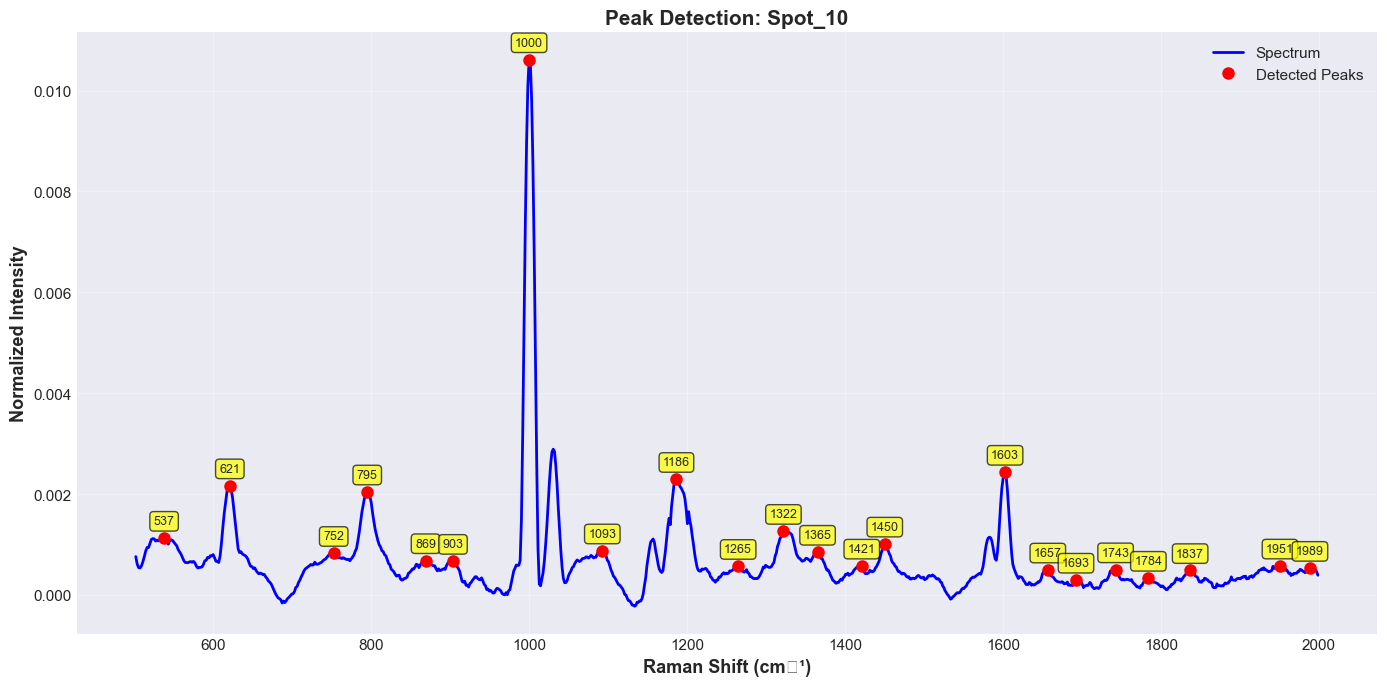

In [50]:
# Visualize peaks for one example spectrum
example_spot = list(raman_data_normalized.keys())[0]

plt.figure(figsize=(14, 7))

# Plot spectrum
plt.plot(raman_data_normalized[example_spot]['shift'], 
         raman_data_normalized[example_spot]['intensity'], 
         label='Spectrum', linewidth=2, color='blue')

# Mark peaks
plt.plot(peak_data[example_spot]['positions'], 
         peak_data[example_spot]['intensities'], 
         'ro', markersize=8, label='Detected Peaks')

# Annotate peaks
for pos, intensity in zip(peak_data[example_spot]['positions'], 
                          peak_data[example_spot]['intensities']):
    plt.annotate(f'{pos:.0f}', 
                xy=(pos, intensity), 
                xytext=(0, 10), 
                textcoords='offset points',
                ha='center', 
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.xlabel('Raman Shift (cm⁻¹)', fontsize=13, fontweight='bold')
plt.ylabel('Normalized Intensity', fontsize=13, fontweight='bold')
plt.title(f'Peak Detection: {example_spot}', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Peak Position Analysis Across All Spots

Create a table showing peak positions and intensities for all 12 spots.

In [51]:
# Compile all peaks into a DataFrame
all_peaks_list = []

for spot_name, peaks in peak_data.items():
    for pos, intensity in zip(peaks['positions'], peaks['intensities']):
        all_peaks_list.append({
            'Spot': spot_name,
            'Peak Position (cm⁻¹)': round(pos, 1),
            'Normalized Intensity': round(intensity, 6)
        })

all_peaks_df = pd.DataFrame(all_peaks_list)

print("All Detected Peaks Across 12 Spots:")
print(all_peaks_df.to_string(index=False))

# Save to Excel
all_peaks_df.to_excel('Peak_Analysis_All_Spots.xlsx', index=False)
print("\n✓ Peak table saved to 'Peak_Analysis_All_Spots.xlsx'")

All Detected Peaks Across 12 Spots:
   Spot  Peak Position (cm⁻¹)  Normalized Intensity
Spot_10                 537.4              0.001125
Spot_10                 620.7              0.002164
Spot_10                 752.3              0.000824
Spot_10                 794.8              0.002043
Spot_10                 868.6              0.000681
Spot_10                 903.4              0.000668
Spot_10                 999.8              0.010614
Spot_10                1092.5              0.000874
Spot_10                1186.4              0.002292
Spot_10                1264.6              0.000567
Spot_10                1322.0              0.001261
Spot_10                1365.2              0.000848
Spot_10                1421.2              0.000573
Spot_10                1450.3              0.001010
Spot_10                1602.7              0.002434
Spot_10                1656.9              0.000495
Spot_10                1692.5              0.000294
Spot_10                1742.

In [52]:
# Find common characteristic peaks (peaks appearing in multiple spots)
from collections import Counter

# Round peak positions to nearest integer for grouping
all_peak_positions = []
for peaks in peak_data.values():
    all_peak_positions.extend([round(pos) for pos in peaks['positions']])

# Count occurrences
peak_counts = Counter(all_peak_positions)

# Find peaks appearing in at least 50% of spots
min_occurrence = len(raman_data_normalized) * 0.5
characteristic_peaks = {pos: count for pos, count in peak_counts.items() 
                       if count >= min_occurrence}

print(f"Characteristic LTA Peaks (appearing in ≥{int(min_occurrence)} spots):\n")
for pos, count in sorted(characteristic_peaks.items()):
    print(f"  {pos} cm⁻¹ → Found in {count}/{len(raman_data_normalized)} spots")

print(f"\n✓ Identified {len(characteristic_peaks)} characteristic peaks")

Characteristic LTA Peaks (appearing in ≥6 spots):

  621 cm⁻¹ → Found in 8/12 spots
  795 cm⁻¹ → Found in 11/12 spots
  1000 cm⁻¹ → Found in 11/12 spots
  1094 cm⁻¹ → Found in 7/12 spots
  1185 cm⁻¹ → Found in 6/12 spots
  1603 cm⁻¹ → Found in 9/12 spots
  1784 cm⁻¹ → Found in 6/12 spots

✓ Identified 7 characteristic peaks


---
## 9. Average Spectrum with Standard Deviation

Create a representative spectrum for the entire powder sample.

In [53]:
# Since all spectra should have the same x-axis, use the first one as reference
reference_shift = raman_data_normalized[list(raman_data_normalized.keys())[0]]['shift']

# Stack all intensity arrays
intensity_matrix = np.array([data['intensity'] for data in raman_data_normalized.values()])

# Calculate mean and standard deviation
mean_intensity = np.mean(intensity_matrix, axis=0)
std_intensity = np.std(intensity_matrix, axis=0)

print("✓ Average spectrum calculated")
print(f"  Mean intensity range: {mean_intensity.min():.6f} to {mean_intensity.max():.6f}")
print(f"  Average std deviation: {std_intensity.mean():.6f}")

✓ Average spectrum calculated
  Mean intensity range: -0.000155 to 0.009799
  Average std deviation: 0.000116


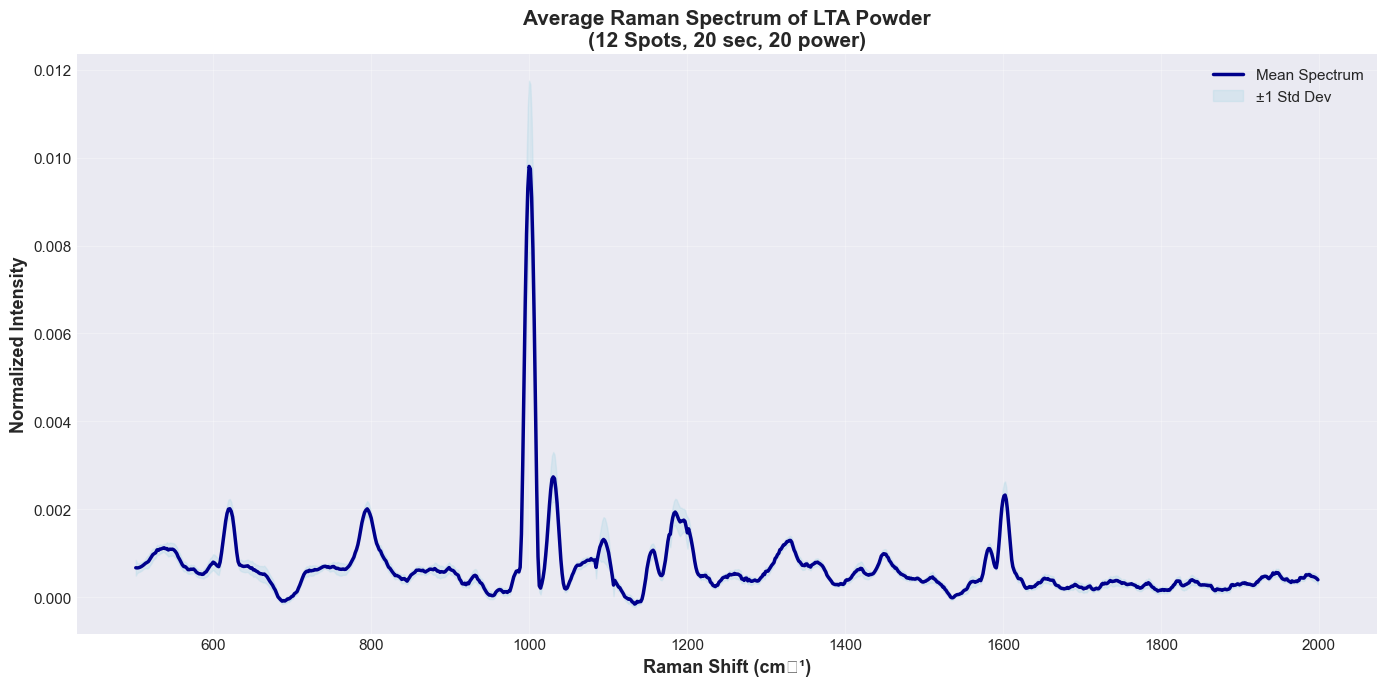

✓ Figure saved as 'Average_Spectrum_LTA.png'


In [54]:
# Plot average spectrum with error band
plt.figure(figsize=(14, 7))

# Plot mean
plt.plot(reference_shift, mean_intensity, 
         linewidth=2.5, color='darkblue', label='Mean Spectrum')

# Plot standard deviation as shaded area
plt.fill_between(reference_shift, 
                 mean_intensity - std_intensity, 
                 mean_intensity + std_intensity, 
                 alpha=0.3, color='lightblue', label='±1 Std Dev')

plt.xlabel('Raman Shift (cm⁻¹)', fontsize=13, fontweight='bold')
plt.ylabel('Normalized Intensity', fontsize=13, fontweight='bold')
plt.title('Average Raman Spectrum of LTA Powder\n(12 Spots, 20 sec, 20 power)', 
          fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Average_Spectrum_LTA.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved as 'Average_Spectrum_LTA.png'")

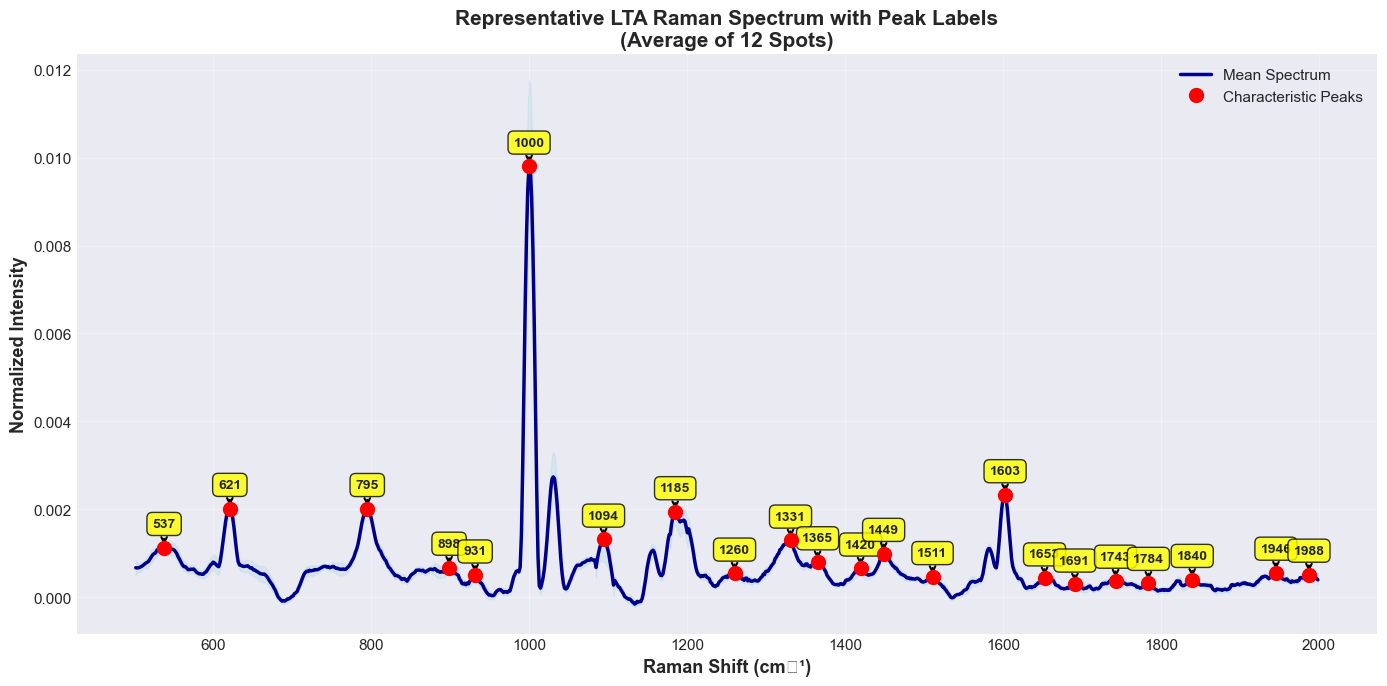

✓ Detected 22 peaks in average spectrum
✓ Figure saved as 'LTA_Labeled_Spectrum.png'


In [55]:
# Detect peaks in average spectrum
avg_peaks, avg_properties = find_peaks(mean_intensity, 
                                       prominence=prominence,
                                       distance=distance)

avg_peak_positions = reference_shift[avg_peaks]
avg_peak_intensities = mean_intensity[avg_peaks]

# Plot average spectrum with labeled peaks
plt.figure(figsize=(14, 7))

plt.plot(reference_shift, mean_intensity, 
         linewidth=2.5, color='darkblue', label='Mean Spectrum')

plt.fill_between(reference_shift, 
                 mean_intensity - std_intensity, 
                 mean_intensity + std_intensity, 
                 alpha=0.3, color='lightblue')

# Mark peaks
plt.plot(avg_peak_positions, avg_peak_intensities, 
         'ro', markersize=10, label='Characteristic Peaks', zorder=5)

# Annotate peaks
for pos, intensity in zip(avg_peak_positions, avg_peak_intensities):
    plt.annotate(f'{pos:.0f}', 
                xy=(pos, intensity), 
                xytext=(0, 15), 
                textcoords='offset points',
                ha='center', 
                fontsize=10,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.8),
                arrowprops=dict(arrowstyle='->', lw=1.5))

plt.xlabel('Raman Shift (cm⁻¹)', fontsize=13, fontweight='bold')
plt.ylabel('Normalized Intensity', fontsize=13, fontweight='bold')
plt.title('Representative LTA Raman Spectrum with Peak Labels\n(Average of 12 Spots)', 
          fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('LTA_Labeled_Spectrum.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Detected {len(avg_peak_positions)} peaks in average spectrum")
print("✓ Figure saved as 'LTA_Labeled_Spectrum.png'")

---
## 10. Spot-to-Spot Variability Analysis

Quantify the reproducibility across different spatial locations.

In [56]:
# Calculate peak position and intensity variability for characteristic peaks
variability_data = []

# For each characteristic peak, calculate statistics across spots
for char_peak in sorted(characteristic_peaks.keys()):
    # Find this peak in each spot (within ±5 cm⁻¹ tolerance)
    peak_positions_at_char = []
    peak_intensities_at_char = []
    
    for spot_name, peaks in peak_data.items():
        # Find peaks near this characteristic position
        nearby_peaks = np.where(np.abs(peaks['positions'] - char_peak) <= 5)[0]
        if len(nearby_peaks) > 0:
            # Take the closest peak
            closest_idx = nearby_peaks[np.argmin(np.abs(peaks['positions'][nearby_peaks] - char_peak))]
            peak_positions_at_char.append(peaks['positions'][closest_idx])
            peak_intensities_at_char.append(peaks['intensities'][closest_idx])
    
    if len(peak_positions_at_char) > 0:
        # Calculate statistics
        pos_mean = np.mean(peak_positions_at_char)
        pos_std = np.std(peak_positions_at_char)
        int_mean = np.mean(peak_intensities_at_char)
        int_std = np.std(peak_intensities_at_char)
        int_cv = (int_std / int_mean * 100) if int_mean > 0 else 0
        
        variability_data.append({
            'Peak Position (cm⁻¹)': round(pos_mean, 1),
            'Position Std Dev': round(pos_std, 2),
            'Intensity Mean': round(int_mean, 6),
            'Intensity Std Dev': round(int_std, 6),
            'CV (%)': round(int_cv, 2),
            'N Spots': len(peak_positions_at_char)
        })

variability_df = pd.DataFrame(variability_data)

print("Peak Variability Analysis:\n")
print(variability_df.to_string(index=False))

# Save to Excel
variability_df.to_excel('Peak_Variability_Analysis.xlsx', index=False)
print("\n✓ Variability analysis saved to 'Peak_Variability_Analysis.xlsx'")

print("\n📊 Interpretation:")
avg_cv = variability_df['CV (%)'].mean()
if avg_cv < 10:
    print(f"   Average CV = {avg_cv:.2f}% → EXCELLENT uniformity")
elif avg_cv < 20:
    print(f"   Average CV = {avg_cv:.2f}% → GOOD uniformity")
else:
    print(f"   Average CV = {avg_cv:.2f}% → MODERATE variability (inhomogeneous)")

Peak Variability Analysis:

 Peak Position (cm⁻¹)  Position Std Dev  Intensity Mean  Intensity Std Dev  CV (%)  N Spots
                620.1              0.83        0.002021           0.000216   10.68       12
                794.5              0.94        0.002020           0.000157    7.79       12
                999.9              0.45        0.009799           0.001948   19.88       12
               1093.2              1.95        0.001363           0.000512   37.52       11
               1184.6              1.72        0.002007           0.000265   13.20       11
               1602.4              0.61        0.002328           0.000308   13.24       12
               1784.2              0.00        0.000415           0.000062   14.86        6

✓ Variability analysis saved to 'Peak_Variability_Analysis.xlsx'

📊 Interpretation:
   Average CV = 16.74% → GOOD uniformity


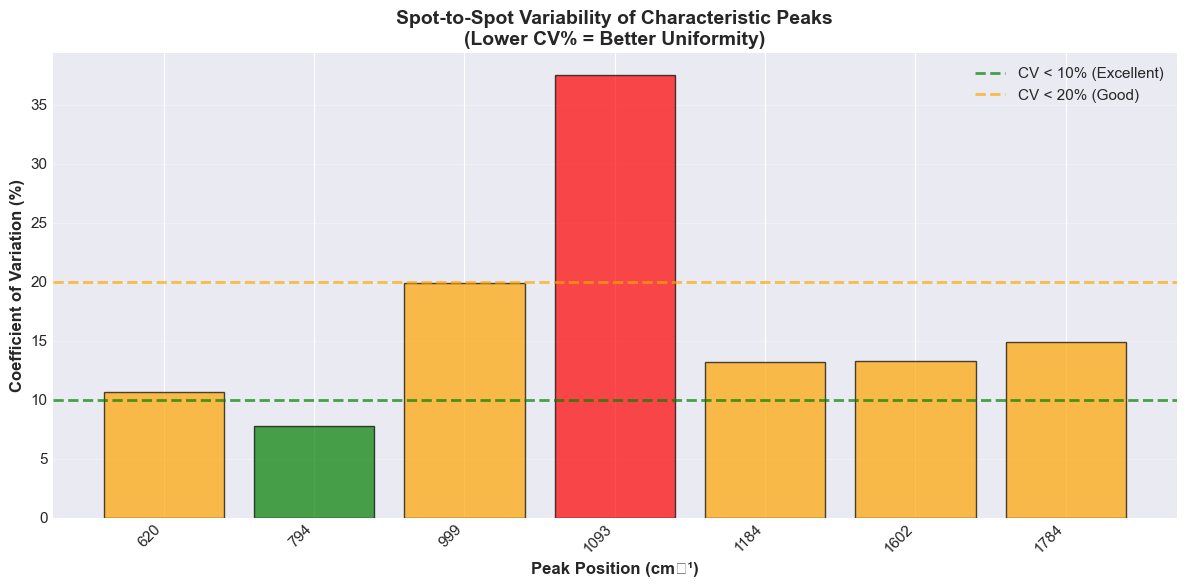

✓ Figure saved as 'Peak_Variability_CV.png'


In [57]:
# Visualize variability: CV% bar chart
plt.figure(figsize=(12, 6))

x_pos = np.arange(len(variability_df))
colors_cv = ['green' if cv < 10 else 'orange' if cv < 20 else 'red' 
             for cv in variability_df['CV (%)']]

plt.bar(x_pos, variability_df['CV (%)'], color=colors_cv, alpha=0.7, edgecolor='black')
plt.xticks(x_pos, [f"{int(p)}" for p in variability_df['Peak Position (cm⁻¹)']], 
           rotation=45, ha='right')
plt.xlabel('Peak Position (cm⁻¹)', fontsize=12, fontweight='bold')
plt.ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
plt.title('Spot-to-Spot Variability of Characteristic Peaks\n(Lower CV% = Better Uniformity)', 
          fontsize=14, fontweight='bold')
plt.axhline(y=10, color='green', linestyle='--', linewidth=2, alpha=0.7, label='CV < 10% (Excellent)')
plt.axhline(y=20, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='CV < 20% (Good)')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('Peak_Variability_CV.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved as 'Peak_Variability_CV.png'")

---
## 11. Overall Spectral Correlation

Calculate correlation between all spot pairs to assess overall similarity.

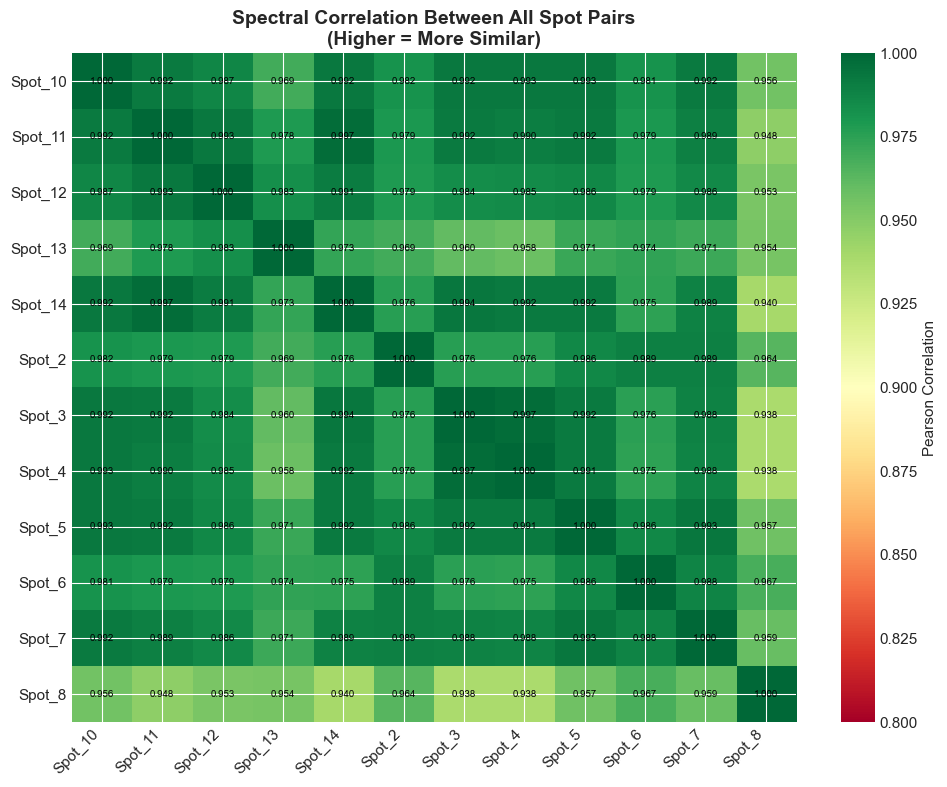


📊 Correlation Statistics:
   Average correlation: 0.9787
   Minimum correlation: 0.9377
   → GOOD spectral reproducibility

✓ Figure saved as 'Spectral_Correlation_Matrix.png'


In [58]:
# Calculate correlation matrix
from scipy.stats import pearsonr

spot_names = list(raman_data_normalized.keys())
n_spots = len(spot_names)
correlation_matrix = np.zeros((n_spots, n_spots))

for i in range(n_spots):
    for j in range(n_spots):
        corr, _ = pearsonr(raman_data_normalized[spot_names[i]]['intensity'],
                          raman_data_normalized[spot_names[j]]['intensity'])
        correlation_matrix[i, j] = corr

# Plot correlation heatmap
plt.figure(figsize=(10, 8))

im = plt.imshow(correlation_matrix, cmap='RdYlGn', vmin=0.8, vmax=1.0, aspect='auto')
plt.colorbar(im, label='Pearson Correlation')

# Add labels
plt.xticks(range(n_spots), spot_names, rotation=45, ha='right')
plt.yticks(range(n_spots), spot_names)

# Add correlation values
for i in range(n_spots):
    for j in range(n_spots):
        text = plt.text(j, i, f'{correlation_matrix[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=7)

plt.title('Spectral Correlation Between All Spot Pairs\n(Higher = More Similar)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Spectral_Correlation_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate statistics
# Exclude diagonal (self-correlation = 1)
off_diagonal = correlation_matrix[np.triu_indices_from(correlation_matrix, k=1)]
avg_correlation = np.mean(off_diagonal)
min_correlation = np.min(off_diagonal)

print(f"\n📊 Correlation Statistics:")
print(f"   Average correlation: {avg_correlation:.4f}")
print(f"   Minimum correlation: {min_correlation:.4f}")

if avg_correlation > 0.98:
    print("   → EXCELLENT spectral reproducibility")
elif avg_correlation > 0.95:
    print("   → GOOD spectral reproducibility")
else:
    print("   → MODERATE variability between spots")

print("\n✓ Figure saved as 'Spectral_Correlation_Matrix.png'")

---
## 12. Final Summary & Export

Create publication-ready figures and export processed data.

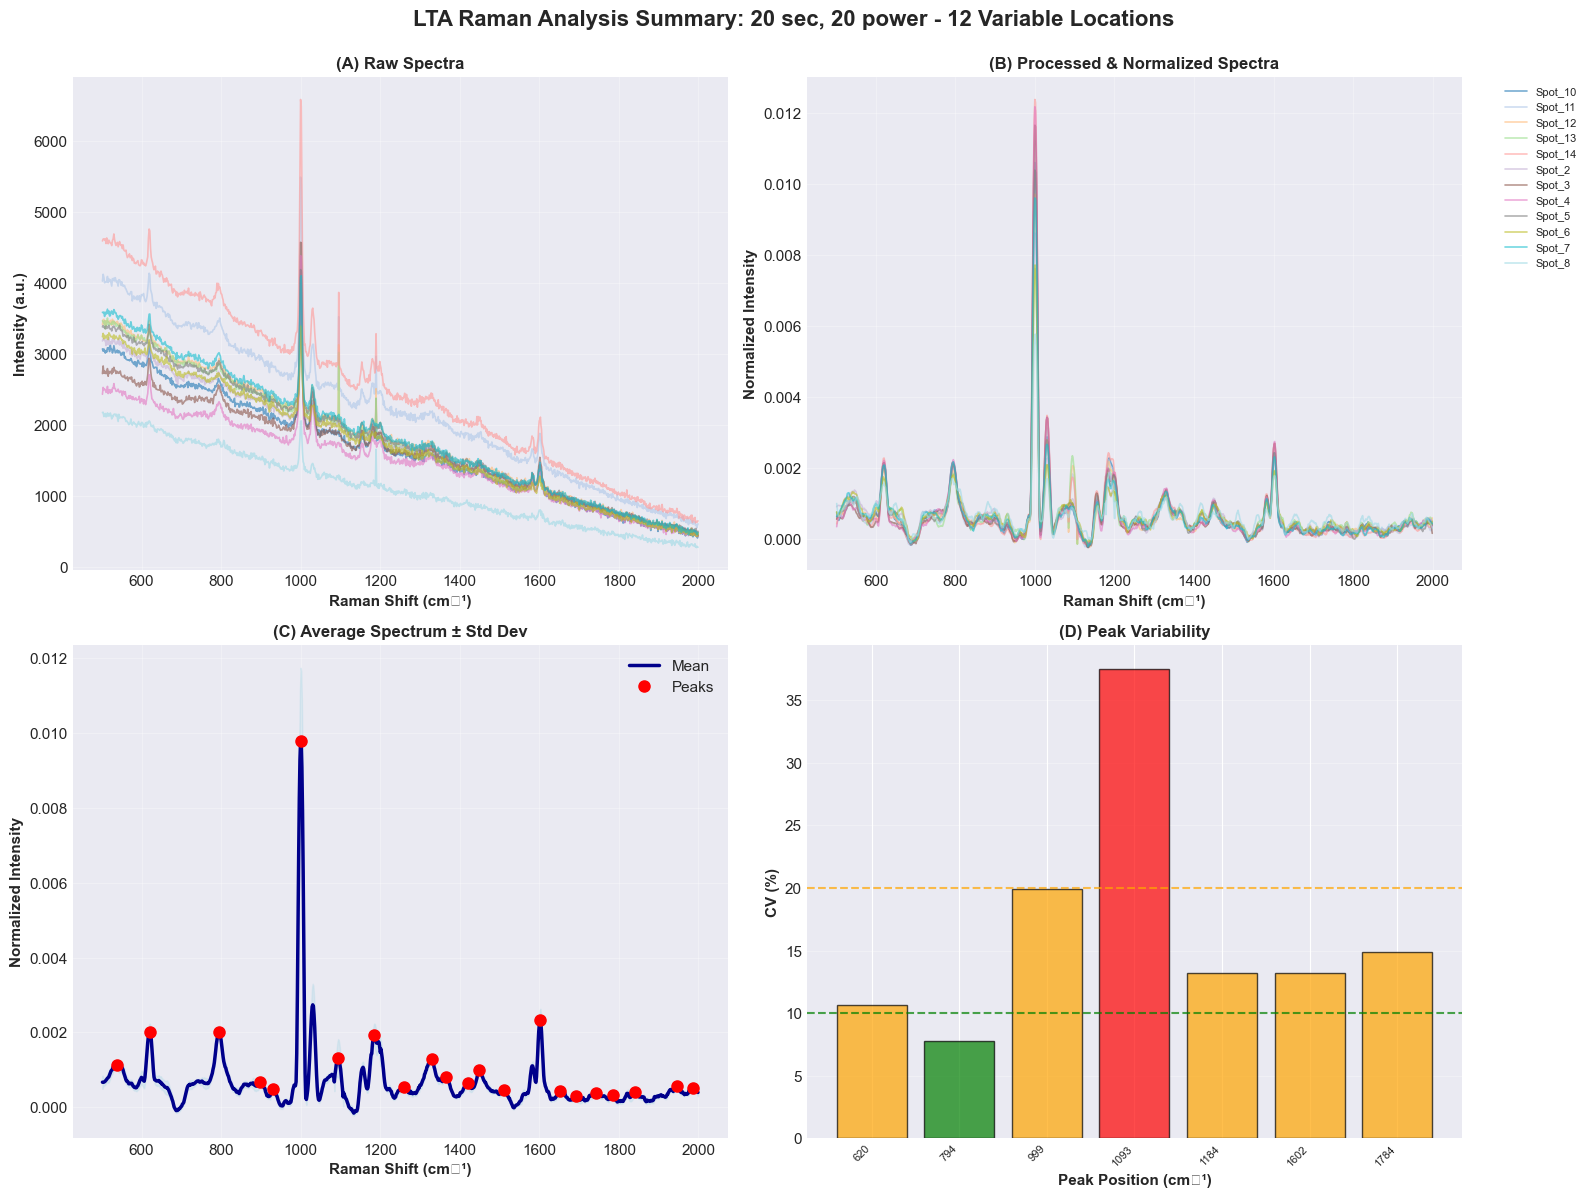

✓ Comprehensive figure saved (PNG & PDF)


In [59]:
# Create comprehensive comparison figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Raw spectra overlay
colors = plt.cm.tab20(np.linspace(0, 1, len(raman_data)))
for idx, (spot_name, data) in enumerate(raman_data.items()):
    axes[0, 0].plot(data['shift'], data['intensity'], 
                   alpha=0.6, linewidth=1.2, color=colors[idx])
axes[0, 0].set_xlabel('Raman Shift (cm⁻¹)', fontweight='bold')
axes[0, 0].set_ylabel('Intensity (a.u.)', fontweight='bold')
axes[0, 0].set_title('(A) Raw Spectra', fontweight='bold', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# 2. Normalized spectra overlay
for idx, (spot_name, data) in enumerate(raman_data_normalized.items()):
    axes[0, 1].plot(data['shift'], data['intensity'], 
                   alpha=0.6, linewidth=1.2, color=colors[idx], label=spot_name)
axes[0, 1].set_xlabel('Raman Shift (cm⁻¹)', fontweight='bold')
axes[0, 1].set_ylabel('Normalized Intensity', fontweight='bold')
axes[0, 1].set_title('(B) Processed & Normalized Spectra', fontweight='bold', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# 3. Average spectrum with peaks
axes[1, 0].plot(reference_shift, mean_intensity, 
               linewidth=2.5, color='darkblue', label='Mean')
axes[1, 0].fill_between(reference_shift, 
                        mean_intensity - std_intensity, 
                        mean_intensity + std_intensity, 
                        alpha=0.3, color='lightblue')
axes[1, 0].plot(avg_peak_positions, avg_peak_intensities, 
               'ro', markersize=8, label='Peaks')
axes[1, 0].set_xlabel('Raman Shift (cm⁻¹)', fontweight='bold')
axes[1, 0].set_ylabel('Normalized Intensity', fontweight='bold')
axes[1, 0].set_title('(C) Average Spectrum ± Std Dev', fontweight='bold', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Variability bar chart
x_pos = np.arange(len(variability_df))
colors_cv = ['green' if cv < 10 else 'orange' if cv < 20 else 'red' 
             for cv in variability_df['CV (%)']]
axes[1, 1].bar(x_pos, variability_df['CV (%)'], color=colors_cv, alpha=0.7, edgecolor='black')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels([f"{int(p)}" for p in variability_df['Peak Position (cm⁻¹)']], 
                          rotation=45, ha='right', fontsize=8)
axes[1, 1].axhline(y=10, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1, 1].axhline(y=20, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1, 1].set_xlabel('Peak Position (cm⁻¹)', fontweight='bold')
axes[1, 1].set_ylabel('CV (%)', fontweight='bold')
axes[1, 1].set_title('(D) Peak Variability', fontweight='bold', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('LTA Raman Analysis Summary: 20 sec, 20 power - 12 Variable Locations', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('LTA_Comprehensive_Analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('LTA_Comprehensive_Analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comprehensive figure saved (PNG & PDF)")

In [60]:
# Export processed data to Excel
with pd.ExcelWriter('LTA_Processed_Spectra.xlsx', engine='openpyxl') as writer:
    # Sheet 1: Average spectrum
    avg_spectrum_df = pd.DataFrame({
        'Raman Shift (cm⁻¹)': reference_shift,
        'Mean Intensity': mean_intensity,
        'Std Dev': std_intensity
    })
    avg_spectrum_df.to_excel(writer, sheet_name='Average Spectrum', index=False)
    
    # Sheet 2: All normalized spectra
    all_spectra_df = pd.DataFrame({'Raman Shift (cm⁻¹)': reference_shift})
    for spot_name, data in raman_data_normalized.items():
        all_spectra_df[spot_name] = data['intensity']
    all_spectra_df.to_excel(writer, sheet_name='All Normalized Spectra', index=False)
    
    # Sheet 3: Peak positions
    all_peaks_df.to_excel(writer, sheet_name='All Peaks', index=False)
    
    # Sheet 4: Variability analysis
    variability_df.to_excel(writer, sheet_name='Peak Variability', index=False)

print("✓ All processed data exported to 'LTA_Processed_Spectra.xlsx'")

✓ All processed data exported to 'LTA_Processed_Spectra.xlsx'


---
## 📊 Final Analysis Summary

In [61]:
print("="*70)
print("         LTA RAMAN ANALYSIS - FINAL SUMMARY")
print("="*70)
print(f"\n📁 Sample: LTA Powder")
print(f"⚡ Acquisition: 20 sec integration, 20 power")
print(f"📍 Number of spots analyzed: {len(raman_data)}")
print(f"\n🔬 PROCESSING STEPS COMPLETED:")
print(f"   ✓ Baseline correction (Asymmetric Least Squares)")
print(f"   ✓ Savitzky-Golay smoothing (window={window_length}, order={polyorder})")
print(f"   ✓ Area normalization")
print(f"   ✓ Peak detection")
print(f"\n🎯 KEY FINDINGS:")
print(f"   • Total characteristic peaks: {len(characteristic_peaks)}")
print(f"   • Average peak CV: {variability_df['CV (%)'].mean():.2f}%")
print(f"   • Spectral correlation: {avg_correlation:.4f}")
print(f"\n📈 MATERIAL HOMOGENEITY:")
if avg_correlation > 0.98 and variability_df['CV (%)'].mean() < 10:
    print("   ⭐ EXCELLENT - Highly uniform powder")
elif avg_correlation > 0.95 and variability_df['CV (%)'].mean() < 20:
    print("   ✅ GOOD - Acceptable uniformity")
else:
    print("   ⚠️  MODERATE - Some spatial inhomogeneity detected")
print(f"\n📂 EXPORTED FILES:")
print(f"   • LTA_Comprehensive_Analysis.png/pdf")
print(f"   • Average_Spectrum_LTA.png")
print(f"   • LTA_Labeled_Spectrum.png")
print(f"   • Peak_Variability_CV.png")
print(f"   • Spectral_Correlation_Matrix.png")
print(f"   • LTA_Processed_Spectra.xlsx")
print(f"   • Peak_Analysis_All_Spots.xlsx")
print(f"   • Peak_Variability_Analysis.xlsx")
print("\n" + "="*70)
print("                    ✨ ANALYSIS COMPLETE ✨")
print("="*70)

         LTA RAMAN ANALYSIS - FINAL SUMMARY

📁 Sample: LTA Powder
⚡ Acquisition: 20 sec integration, 20 power
📍 Number of spots analyzed: 12

🔬 PROCESSING STEPS COMPLETED:
   ✓ Baseline correction (Asymmetric Least Squares)
   ✓ Savitzky-Golay smoothing (window=15, order=3)
   ✓ Area normalization
   ✓ Peak detection

🎯 KEY FINDINGS:
   • Total characteristic peaks: 7
   • Average peak CV: 16.74%
   • Spectral correlation: 0.9787

📈 MATERIAL HOMOGENEITY:
   ✅ GOOD - Acceptable uniformity

📂 EXPORTED FILES:
   • LTA_Comprehensive_Analysis.png/pdf
   • Average_Spectrum_LTA.png
   • LTA_Labeled_Spectrum.png
   • Peak_Variability_CV.png
   • Spectral_Correlation_Matrix.png
   • LTA_Processed_Spectra.xlsx
   • Peak_Analysis_All_Spots.xlsx
   • Peak_Variability_Analysis.xlsx

                    ✨ ANALYSIS COMPLETE ✨


---
## 🔬 Scientific Interpretation

### What We Analyzed:
- **Reproducibility** of Raman spectral signature across 12 spatial locations
- **Material homogeneity** of LTA powder under consistent acquisition conditions
- **Structural consistency** across different sampling points

### Importance:
1. **Material Quality Control**: Low CV% indicates uniform LTA synthesis
2. **SERS Substrate Consistency**: High correlation ensures reproducible measurements
3. **Structural Stability**: Consistent peak positions suggest uniform crystal structure

### Next Steps:
- Compare with different acquisition parameters (integration time, laser power)
- Compare with other LTA batches or synthesis conditions
- Assign specific vibrational modes to characteristic peaks (literature comparison)